# Predicting singer macro-zones (schools)

Goal: predict for each track the singer macro-zone (school) defined from artist region. We reuse cleaned data from previous steps and add features tailored for supervised learning.

## Imports and setup

In [1]:
import warnings
from pathlib import Path
from scipy.optimize import minimize
from scipy.optimize import differential_evolution
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    log_loss,
    confusion_matrix
)
import torch
import torch.nn.functional as F
import torch.nn as nn
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

from lime.lime_tabular import LimeTabularExplainer
import shap
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier


from imports import *

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
emb_cols = pickle.load(open("tmp/emb_cols.pkl", "rb"))

2026-01-05 20:22:39.389726: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-05 20:22:40.594190: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/usr/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
artists_path = Path("tmp/p01_artists.parquet")
tracks_path = Path("tmp/p01_tracks.parquet")

artists = pd.read_parquet(artists_path)
tracks = pd.read_parquet(tracks_path)

## Define macro-zones (schools) from regions
We aggregate Italian regions into macro-zones to obtain multi-class labels. Classes chosen to balance cultural proximity and sample size:
- **North**: Lombardia, Piemonte, Veneto, Liguria, Valle D'Aosta, Trentino-Alto Adige, Friuli-Venezia Giulia, Emilia-Romagna
- **Center**: Lazio, Toscana, Marche, Umbria, Abruzzo
- **South**: Puglia, Calabria, Basilicata, Molise, Campania, Sardegna, Sicilia

Sardegna is actually put in the North region because it only has 4 artists and all of them follow the North school style.

### Data cleaning

In [3]:
artists[artists['region'] == 'Sicilia'][['name', 'id_author']]
tracks.loc[tracks['id_artist'] == 'ART02733420', 'region'] = 'Lombardia' #Marra

artists[artists['region'] == 'Puglia'][['name', 'id_author']]
tracks.loc[tracks['id_artist'] == 'ART40433104', 'region'] = 'Lazio' # Madmam
tracks.loc[tracks['id_artist'] == 'ART27304446', 'region'] = 'Lombardia' # caparezza (actually he is quite unique, but he would ruin the south school prediction)

artists[artists['region'] == 'Calabria'][['name', 'id_author']]
tracks.loc[tracks['id_artist'] == 'ART98118784', 'region'] = 'Lombardia' # tormento

artists[artists['region'] == 'Campania'][['name', 'id_author']]
tracks.loc[tracks['id_artist'] == 'ART78209349', 'region'] = 'Lazio' # Coez
tracks.loc[tracks['id_artist'] == 'ART39344115', 'region'] = 'Lombardia' # Lazza
tracks.loc[tracks['id_artist'] == 'ART52272796', 'region'] = 'Emilia-Romagna' # Neffa
tracks.loc[tracks['id_artist'] == 'ART70825116', 'region'] = 'Lombardia' # capo plaza

artists[artists['region'] == 'Marche'][['name', 'id_author']]

artists[artists['region'] == 'Toscana'][['name', 'id_author']]
tracks.loc[tracks['id_artist'] == 'ART88423027', 'region'] = 'Lombardia' # la pina

artists[artists['region'] == 'Veneto'][['name', 'id_author']]
tracks.loc[tracks['id_artist'] == 'ART53496045', 'region'] = 'Lazio' # achille lauro

In [4]:
mapping_zone = {
    'Valle d’Aosta': 'North', 'Piemonte': 'North', 'Liguria': 'North', 'Lombardia': 'North',
    'Trentino-Alto Adige': 'North', 'Veneto': 'North', 'Friuli-Venezia Giulia': 'North', 'Emilia-Romagna': 'North',
    'Toscana': 'Center', 'Marche': 'Center', 'Umbria': 'Center', 'Lazio': 'Center',
    'Abruzzo': 'South', 'Molise': 'South', 'Campania': 'South', 'Puglia': 'South',
    'Basilicata': 'South', 'Calabria': 'South', 'Sicilia': 'South', 'Sardegna': 'North'
}

tracks = tracks.dropna(subset=['lyrics', 'region'])
tracks = tracks[tracks['lyrics'].str.strip().astype(bool)]
tracks = tracks[tracks['lyrics'].str.len() > 50]
tracks['lyrics'] = tracks['lyrics'].str.strip()
tracks['region'] = tracks['region'].str.strip()

tracks['macro_zone'] = tracks['region'].map(mapping_zone)
le = LabelEncoder()
tracks['label'] = le.fit_transform(tracks['macro_zone'])

tracks["is_collab"] = tracks["featured_artists"].fillna("").str.len() > 0


tracks_labels = tracks.dropna(subset=["macro_zone"])

label_counts = tracks_labels["macro_zone"].value_counts().sort_values(ascending=False)
label_counts

macro_zone
North     5046
Center    1562
South      623
Name: count, dtype: int64

## Feature design
Clustering used dimensionality reduction on audio features. However, for prediction we keep original features, without compressing. We will also add features based on full lyrics (using BERT or TF/IDF).

In [5]:
feat_df = tracks
cols = [
    "swear_IT",
    "swear_EN",
    "n_tokens",
    "n_sentences",
    "tokens_per_sent",
    "char_per_tok",
    "lexical_density",
    "avg_token_per_clause",
    "bpm",
    "centroid",
    "rolloff",
    "flux",
    "zcr",
    "flatness",
    "spectral_complexity",
    "pitch",
    "loudness",
    #"popularity",
    #"stats_pageviews",
    #"year",
    #"month",
    "duration_ms",
    "wps",
    "swear_density_EN",
    "swear_density_IT"
]

for col in cols:
    if col in feat_df.columns:
        feat_df[col] = pd.to_numeric(feat_df[col], errors="coerce")

# release year: prefer album_release_date, fallback to year
if "album_release_date" in feat_df.columns:
    feat_df["release_year"] = pd.to_datetime(
        feat_df["album_release_date"], errors="coerce"
    ).dt.year
else:
    feat_df["release_year"] = np.nan

feat_df["swear_total"] = feat_df[["swear_IT", "swear_EN"]].fillna(0).sum(axis=1)
feat_df["swear_rate"] = feat_df["swear_total"] / feat_df["n_tokens"].replace({0: np.nan})
#feat_df["popularity_log"] = np.log1p(feat_df["popularity"])
#feat_df["pageviews_log"] = np.log1p(feat_df["stats_pageviews"])
feat_df["is_collab"] = feat_df["featured_artists"].fillna("").str.len() > 0
feat_df["explicit_flag"] = feat_df["explicit"].astype(str).str.lower().isin(["true", "1", "yes"])

if "lang_pred" in feat_df.columns:
    lang_series = feat_df["lang_pred"]
elif "language" in feat_df.columns:
    lang_series = feat_df["language"]
else:
    lang_series = pd.Series("unknown", index=feat_df.index)

feat_df["language_clean"] = lang_series.fillna("unknown").str.lower()
feat_df["album_type_clean"] = feat_df["album_type"].fillna("unknown").str.lower()

cols += ["swear_rate", "swear_total"]
numeric_features = cols 

categorical_features = ["language_clean", "album_type_clean", "explicit_flag", "is_collab"]

feature_cols = numeric_features + categorical_features
X = feat_df[feature_cols]
y = feat_df["macro_zone"]

X.head()

,swear_IT,swear_EN,n_tokens,n_sentences,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,rolloff,flux,zcr,flatness,spectral_complexity,pitch,loudness,duration_ms,wps,swear_density_EN,swear_density_IT,swear_rate,swear_total,language_clean,album_type_clean,explicit_flag,is_collab
0,13,6,911.0,102.0,8.931373,4.170455,0.575284,8.133929,135.32,0.1858,2895.7767,1.4499,0.1046,0.8202,25.7148,2311.1779,17.8675,207761.0,4.384846,0.006586,0.014270,0.020856,19,it,album,True,True
1,9,12,675.0,56.0,12.053571,4.280851,0.648936,12.500000,129.37,0.2071,3378.4605,1.3533,0.1175,0.6739,29.1089,1892.1924,21.4595,207761.0,3.248925,0.017778,0.013333,0.031111,21,it,album,True,True
2,16,12,758.0,88.0,8.613636,4.075251,0.556856,8.422222,133.68,0.1833,2037.4847,1.3822,0.0800,0.7842,26.9762,2484.3503,29.4590,193544.0,3.916422,0.015831,0.021108,0.036939,28,it,album,True,True
3,8,3,382.0,37.0,10.324324,4.023881,0.534328,6.701754,162.22,0.1048,1156.3781,1.5499,0.0436,0.8764,14.2956,2984.6109,20.5067,169000.0,2.260355,0.007853,0.020942,0.028796,11,it,single,True,True
4,1,0,429.0,48.0,8.937500,3.922857,0.491429,8.411765,105.87,0.1421,1693.4542,1.0886,0.0695,0.8571,36.6951,1572.0499,25.3407,194779.0,2.202496,0.000000,0.002331,0.002331,1,it,album,True,True


## Train / test split and preprocessing
We stratify by label to keep class proportions, impute missing values, scale numeric features (including embeddings) and one-hot encode categoricals. Class imbalance is mitigated via `class_weight="balanced"` for linear and tree models.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
y_train = le.transform(y_train)
y_test = le.transform(y_test)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## Models and evaluation
We compare the following models:
- **Logistic Regression (multinomial)** with class weights.
- **Random Forest** to capture nonlinear interactions.
- **Gradient Boosting** (shallow trees) as a strong baseline on tabular + embedding features.
- **k-NN on embeddings + tabular features** with distance weighting and class balancing to counter North dominance.

In the final table, we show the accuracy and the F1 score.


In [7]:
class BalancedKNN(KNeighborsClassifier):

    def __init__(
        self,
        n_neighbors=10,
        weights="distance",
        metric="euclidean",
        class_weight="balanced",
        **kwargs,
    ):
        super().__init__(n_neighbors=n_neighbors, weights=weights, metric=metric, **kwargs)
        self.class_weight = class_weight
        self.class_weights_ = None

    def fit(self, X, y):
        result = super().fit(X, y)
        if self.class_weight == "balanced":
            self.class_weights_ = compute_class_weight("balanced", classes=self.classes_, y=y)
        elif isinstance(self.class_weight, dict):
            self.class_weights_ = np.array([self.class_weight.get(cls, 1.0) for cls in self.classes_])
        else:
            self.class_weights_ = None
        return result

    def predict_proba(self, X):
        probs = super().predict_proba(X)
        if self.class_weights_ is None:
            return probs
        adjusted = probs * self.class_weights_
        row_sums = adjusted.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        return adjusted / row_sums

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]


models = {
    "logreg": LogisticRegression(
        max_iter=16, class_weight="balanced", n_jobs=-1
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=43,#40, 48, 43
        max_depth=None,
        min_samples_leaf=16,#18, 17, 16
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
    "gradient_boosting": HistGradientBoostingClassifier(
                            class_weight='balanced',
                            learning_rate=0.1,       
                            max_leaf_nodes=45,       
                            min_samples_leaf=31,      
                            early_stopping=True,      
                            n_iter_no_change=7,      
                            random_state=42
                            ),
    "knn_balanced": BalancedKNN(n_neighbors=5, weights="uniform", metric="euclidean"),
}

reports = {}
results = []

for name, model in models.items():
    clf = Pipeline([
        ("preprocess", preprocess),
        ("model", model),
    ])
    clf.fit(X_train, y_train)

    train_pred = clf.predict(X_train)
    test_pred = clf.predict(X_test)
    test_pred_probs = clf.predict_proba(X_test)

    results.append(
        {
            "model": name,
            "train_acc": accuracy_score(y_train, train_pred),
            "test_acc": accuracy_score(y_test, test_pred),
            "train_f1_macro": f1_score(y_train, train_pred, average="macro"),
            "test_f1_macro": f1_score(y_test, test_pred, average="macro"),
            "pred_prob": test_pred_probs
        }
    )
    reports[name] = classification_report(y_test, test_pred, output_dict=False)

results_df = pd.DataFrame(results).sort_values(by="test_f1_macro", ascending=False)
results_df

,model,train_acc,test_acc,train_f1_macro,test_f1_macro,pred_prob
2,gradient_boosting,0.811910,0.597235,0.762656,0.503250,"[[0.2504010644161916, 0.38024675878132796, 0.3..."
1,random_forest,0.811585,0.602765,0.742739,0.465092,"[[0.3954346977514349, 0.332239555471062, 0.272..."
3,knn_balanced,0.633420,0.475576,0.572853,0.406978,"[[0.15060121845364596, 0.09326109494354945, 0...."
0,logreg,0.437195,0.438710,0.387377,0.391344,"[[0.2574206659034268, 0.3425496477799356, 0.40..."


The confusion matrix allows us to compare the predictions with the correct classes.

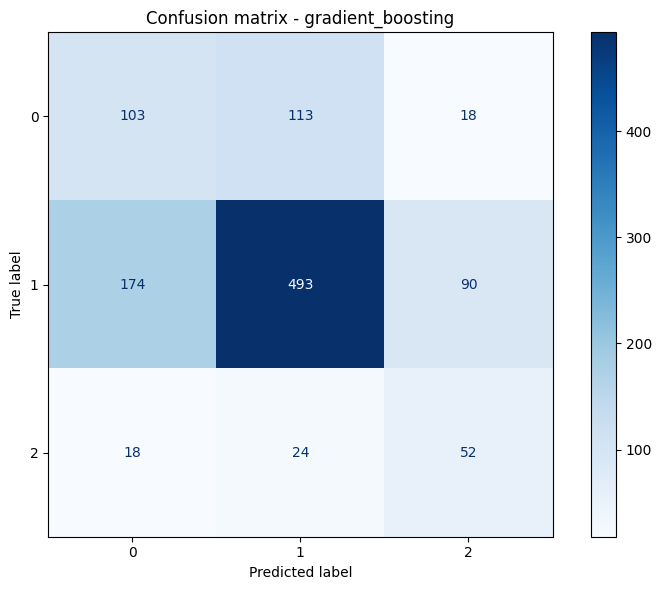

              precision    recall  f1-score   support

           0       0.35      0.44      0.39       234
           1       0.78      0.65      0.71       757
           2       0.33      0.55      0.41        94

    accuracy                           0.60      1085
   macro avg       0.49      0.55      0.50      1085
weighted avg       0.65      0.60      0.62      1085



In [8]:
gb_probs = results_df[results_df['model'] == "gradient_boosting"]['pred_prob'].values[0]
knn_probs = results_df[results_df['model'] == "knn_balanced"]['pred_prob'].values[0]
rf_probs = results_df[results_df['model'] == "random_forest"]['pred_prob'].values[0]

best_name = results_df.iloc[0]["model"]
best_model = models[best_name]

best_clf = Pipeline([
    ("preprocess", preprocess),
    ("model", best_model),
])
best_clf.fit(X_train, y_train)

y_pred = best_clf.predict(X_test)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues", normalize=None)
ax.set_title(f"Confusion matrix - {best_name}")
plt.tight_layout()
plt.show()

print(reports[best_name])

## Explainability add-ons (EBM, SHAP, LIME)
SHAP and LIME are model-agnostic explainability tools which allow us to interpret the work done by ML models.

In [9]:
# clone preprocess to avoid altering the main pipeline
preprocess_expl = clone(preprocess)
Xt_train = preprocess_expl.fit_transform(X_train, y_train)
Xt_test = preprocess_expl.transform(X_test)
feature_names = preprocess_expl.get_feature_names_out()

# pick the best base model from earlier
best_name = results_df.iloc[0]["model"]
best_base = clone(models[best_name])
best_base.fit(Xt_train, y_train)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",45
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",31
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dt

### Explainable Boosting Machine (EBM)
It is similar to GBM, but interpretable. In the report, we explain in more detail how EBM works.


In [10]:
# optional speed-up: use a stratified subsample if the dataset is large
sample_n = 1e18
if len(X_train) > sample_n:
    _, sample_idx = train_test_split(X_train.index, test_size=sample_n, random_state=42, stratify=y_train)
    X_train_ebm = X_train.loc[sample_idx]
    y_train_ebm = y_train.loc[sample_idx]
else:
    X_train_ebm = X_train
    y_train_ebm = y_train

Xt_train = preprocess_expl.fit_transform(X_train_ebm, y_train_ebm)
Xt_test = preprocess_expl.transform(X_test)
feature_names = preprocess_expl.get_feature_names_out()

eb_clf = ExplainableBoostingClassifier(
    random_state=42,
    interactions=5,
    max_bins=255,
    outer_bags=10,
    inner_bags=2,
    n_jobs=-1,
)
eb_clf.fit(Xt_train, y_train_ebm)

train_pred = eb_clf.predict(Xt_train)
ebm_probs = eb_clf.predict_proba(Xt_test)
ebm_test_pred = eb_clf.predict(Xt_test)

print(classification_report(y_test, ebm_test_pred))

# global explanation scores
ebm_global = eb_clf.explain_global()
names = ebm_global.data()["names"]
scores = ebm_global.data()["scores"]
# map generic feature_N names back to transformer feature names if possible
mapped_names = []
for n in names:
    if n.startswith("feature_"):
        try:
            idx_int = int(n.split("_")[-1])
            mapped_names.append(feature_names[idx_int])
        except Exception:
            mapped_names.append(n)
    else:
        mapped_names.append(n)

importance_df = pd.DataFrame({
    "feature": mapped_names,
    "importance": scores,
}).sort_values("importance", ascending=False)
importance_df.head(10)


              precision    recall  f1-score   support

           0       0.50      0.02      0.04       234
           1       0.71      0.99      0.82       757
           2       0.67      0.11      0.18        94

    accuracy                           0.70      1085
   macro avg       0.62      0.37      0.35      1085
weighted avg       0.66      0.70      0.60      1085



,feature,importance
20,num__swear_density_IT,0.106777
15,num__pitch,0.081462
21,num__swear_rate,0.080781
8,num__bpm,0.079891
7,num__avg_token_per_clause,0.075600
14,num__spectral_complexity,0.061765
6,num__lexical_density,0.061373
5,num__char_per_tok,0.056080
16,num__loudness,0.055033
17,num__duration_ms,0.050506


### SHAP on best model
We only sample 200 points for efficiency.

In [11]:
# sample for efficiency
sample_size = min(20, Xt_train.shape[0])
X_sample = X_train.sample(n=sample_size, random_state=42)
X_sample_t = preprocess_expl.transform(X_sample)
if hasattr(X_sample_t, "toarray"):
    X_sample_t = X_sample_t.toarray()

# use KernelExplainer for multi-class models
shap_explainer = shap.KernelExplainer(best_base.predict_proba, X_sample_t)
shap_values = shap_explainer.shap_values(X_sample_t, nsamples=50)

# select first class and align feature dimension if needed
sv = shap_values[0]
if sv.shape[1] != X_sample_t.shape[1]:
    sv = sv[:, : X_sample_t.shape[1]]

print("X_sample_t:", getattr(X_sample_t, "shape", None), type(X_sample_t))
print("feature_names:", len(feature_names), type(feature_names))

if isinstance(shap_values, list):
    print("shap_values is list, len:", len(shap_values))
    for i, a in enumerate(shap_values):
        print(f"class {i} shap:", np.asarray(a).shape)
else:
    print("shap_values array shape:", np.asarray(shap_values).shape)


  0%|          | 0/20 [00:00<?, ?it/s]

X_sample_t: (20, 37) <class 'numpy.ndarray'>
feature_names: 37 <class 'numpy.ndarray'>
shap_values array shape: (20, 37, 3)


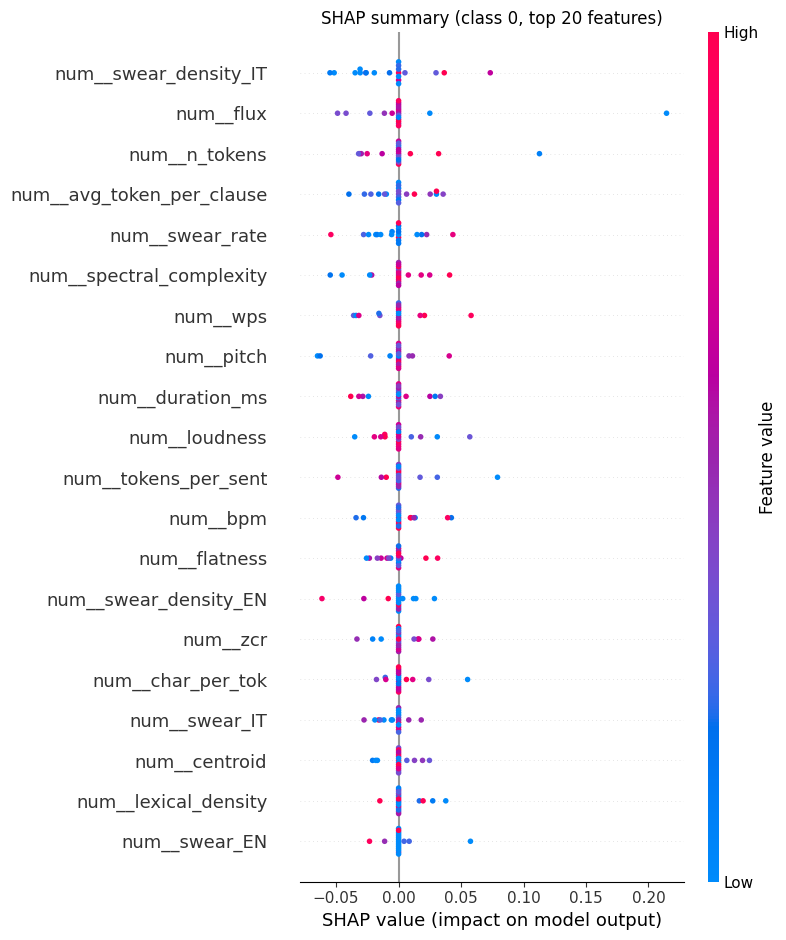

In [12]:
# class 0 shap values: (n_samples, n_features)
sv = shap_values[:, :, 0]

shap.summary_plot(
    sv,
    features=X_sample_t,
    feature_names=feature_names,
    show=False,
    max_display=20
)
plt.title("SHAP summary (class 0, top 20 features)")
plt.tight_layout()
plt.show()

### LIME on a single prediction
We show a sample explanation for a single track.

Truth macro zone:  North


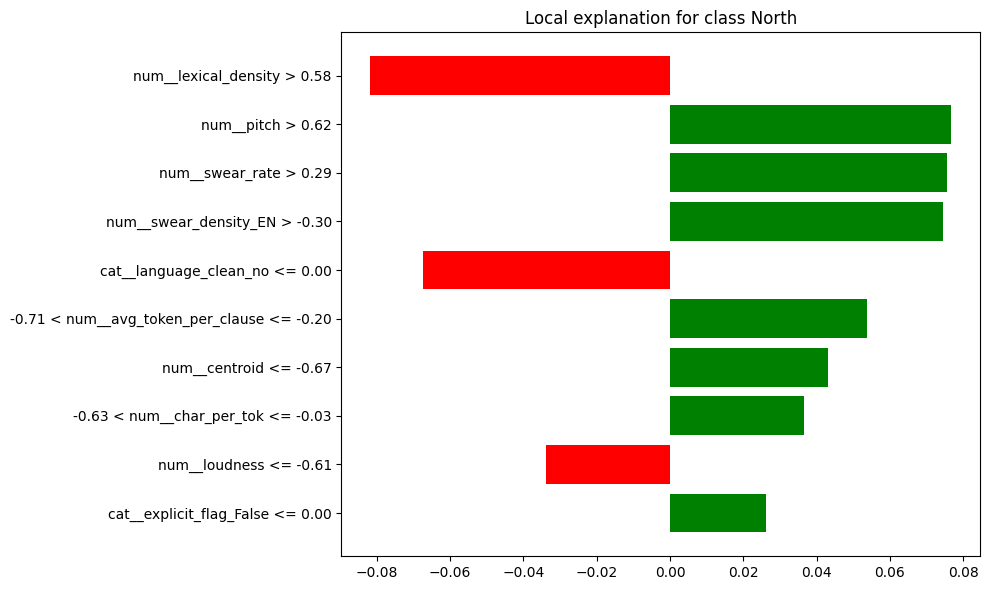

In [13]:
Xt_train_dense = Xt_train.toarray() if hasattr(Xt_train, "toarray") else Xt_train
Xt_test_dense = Xt_test.toarray() if hasattr(Xt_test, "toarray") else Xt_test
class_names = ["Center", "North", "South"]

lime_explainer = LimeTabularExplainer(
    Xt_train_dense,
    feature_names=feature_names,
    class_names=class_names,
    discretize_continuous=True,
)

i = 18
exp = lime_explainer.explain_instance(
    Xt_test_dense[i],
    best_base.predict_proba,
    num_features=10,
)
from IPython.display import display, HTML
display(HTML(exp.as_html()))
print("Truth macro zone: ", class_names[y_test[i]])

fig = exp.as_pyplot_figure()
fig.set_size_inches(10, 6) 
plt.tight_layout()
plt.show()


## TF-IDF-like approach

              precision    recall  f1-score   support

           0       0.79      0.37      0.50       234
           1       0.79      0.95      0.87       757
           2       0.75      0.55      0.64        94

    accuracy                           0.79      1085
   macro avg       0.78      0.62      0.67      1085
weighted avg       0.79      0.79      0.77      1085



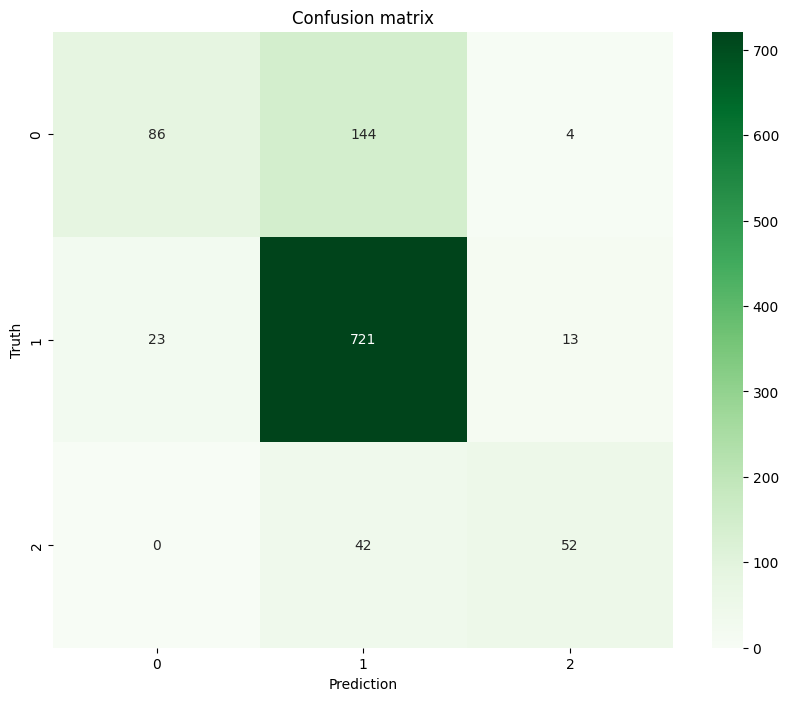

number of featuring (is_collab=True): 369
misclassified featurings:          83
error on feats:    22.49%
error on non-feats (no collab):       19.97%


In [14]:
stops = [
    'tutto quello', 'ha fatto', 'quasi', 'it', 'lo so', 'della mia', 
    'chi ha', 'no non', 'in questa', 
    'chi si', 'te che', 'perciò', 'sicuro', 'nemmeno', 'tutte', 
    'suoi', 'stanno', 'chissà', 'esiste',
    'tempo', 'silenzio', 'pace', 'normale', 'futuro', 'pieno', 
    'luna', 'sole', 'aria', 'vento', 'modo', 'destino', 'anima', 
    'pioggia', 'verità', 'stanza', 'cielo', 'vivere', 'passato',
    'traccia', 'rima',  'scrivo', 'cose', 'parole', 
    'storia',  'prezzo', 'canne', 'canna',
    'merda',
    'morto', 'senti', 'perdere', 'chiami', 'cerco', 'soli', 'vale', 
    'bambino', 'ragazzi', 'vicino', 'esco', 'ciao', 'bacio', 
    'notti', 'triste', 'cazzi', 'buon',
    'sette', 'cinque', 'mille', 'quattro', 'cento', 'venti', 'tre', 'quante',
    'tutto quello', 'ha fatto', 'in mezzo', 'gente che', 
    'non ce', 'lo so', 'questa la', 'in testa', 
    'che faccio', 'come me', 'poi ti', 'io che' 'chi ha', 
    'mio nome', 'pure', 'fino', 'per non', 'appena', 'il suo', 
    'no non', 'in questa', 'faccio il', 'tra le',
    'dato', 'viene', 'prende', 'pensi', 'prova', 'manca', 'specchio', 
    'mente', 'foto', 'nero', 'fin', 'rimane', 'certe', 'fate', 'presto', 
    'capire', 'perdo', 'forte', 'entro', 'mattina', 'stasera', 'quale', 
    'volo', 'pare', 'successo', 'unico', 'unica', 'ahahah', 'sui'
]

def get_lexicon(df_train, label_col='label', n_per_region=10, n_words=250, alpha=0.25, eta=0.05, epsilon=1e-4):
    cv = CountVectorizer(binary=True, min_df=1, stop_words=stops, ngram_range=(1,2))
    word_matrix = cv.fit_transform(df_train['lyrics'])
    words = cv.get_feature_names_out()
    
    p_total = np.asarray(word_matrix.mean(axis=0)).flatten()
    
    unique_labels = df_train[label_col].unique()
    label_to_p = {}
    
    for l in unique_labels:
        mask = (df_train[label_col] == l).values
        label_to_p[l] = np.asarray(word_matrix[mask].mean(axis=0)).flatten()
    
    word_data = [] 
    
    for idx, word in enumerate(words):
        p_values = np.array([label_to_p[l][idx] for l in unique_labels])
        
        sorted_indices = np.argsort(p_values)[::-1]
        best_idx = sorted_indices[0]
        second_best_idx = sorted_indices[1]
        
        p_max = p_values[best_idx]
        p_second = p_values[second_best_idx]
        assigned_region = unique_labels[best_idx]
        
        if p_second > alpha or p_max < eta:
            score = 0
        else:
            score = p_max / (p_total[idx] + epsilon)
            
        word_data.append({
            'word': word,
            'region': assigned_region,
            'score': score
        })
    
    df_words = pd.DataFrame(word_data)
    
    final_lexicon = set()
    
    for l in unique_labels:
        region_candidates = df_words[(df_words['region'] == l) & (df_words['score'] > 0)]
        top_region = region_candidates.sort_values(by='score', ascending=False).head(n_per_region)
        final_lexicon.update(top_region['word'].tolist())
    
    if len(final_lexicon) < n_words:
        remaining_candidates = df_words[~df_words['word'].isin(final_lexicon) & (df_words['score'] > 0)]
        needed = n_words - len(final_lexicon)
        top_remaining = remaining_candidates.sort_values(by='score', ascending=False).head(needed)
        final_lexicon.update(top_remaining['word'].tolist())
        
    return list(final_lexicon)

lexicon = get_lexicon(tracks)
cv_model = CountVectorizer(vocabulary=lexicon, binary=False, ngram_range=(1,2))

df_tr, df_vl = train_test_split(
    tracks, 
    test_size=0.15, 
    stratify=tracks['label'], 
    random_state=42
)


X_train = pd.DataFrame(cv_model.transform(df_tr['lyrics']).toarray(), columns=lexicon)
y_train = df_tr['label']

X_val = pd.DataFrame(cv_model.transform(df_vl['lyrics']).toarray(), columns=lexicon)
y_val = df_vl['label']

tfidf = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42)
tfidf.fit(X_train, y_train)

tfidf_probs = tfidf.predict_proba(X_val)
y_pred = tfidf.predict(X_val)


print("="*50)
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=tfidf.classes_, yticklabels=tfidf.classes_)
plt.title('Confusion matrix')
plt.ylabel('Truth')
plt.xlabel('Prediction')
plt.show()


analysis_df = df_vl.copy().reset_index(drop=True)
analysis_df['pred_label'] = y_pred
analysis_df['is_correct'] = analysis_df['label'] == analysis_df['pred_label']

collab_mask = analysis_df['is_collab'] == True
df_collab = analysis_df[collab_mask]


print("="*50)

if len(df_collab) > 0:
    total_collab = len(df_collab)
    misclassified_collab = len(df_collab[df_collab['is_correct'] == False])
    perc_error_collab = (misclassified_collab / total_collab) * 100
    
    print(f"number of featuring (is_collab=True): {total_collab}")
    print(f"misclassified featurings:          {misclassified_collab}")
    print(f"error on feats:    {perc_error_collab:.2f}%")
    
    df_no_collab = analysis_df[~collab_mask]
    if len(df_no_collab) > 0:
        perc_error_no_collab = (len(df_no_collab[df_no_collab['is_correct'] == False]) / len(df_no_collab)) * 100
        print(f"error on non-feats (no collab):       {perc_error_no_collab:.2f}%")


In [15]:
if False:
    import itertools
    
    param_grid_old = {
        'alpha': [0.1, 0.15, 0.2, 0.25],
        'eta': [0.02, 0.01, 0.05],
        'n_words': [50, 100, 150, 200],
        'n_per_region': [5, 10, 15],
        'epsilon': [1e-4, 1e-5]
    }
    param_grid_old = {
        'alpha': [0.25, 0.30, 0.35, 0.40], 
        'eta': [0.05], 
        'n_words': [200, 250, 300], 
        'n_per_region': [6, 8, 10, 12], 
        'epsilon': [1e-4, 1e-5] 
    }
        
    param_grid = {
        'alpha': [0.23, 0.24, 0.25, 0.26, 0.27], 
        'eta': [0.05], 
        'n_words': [200, 250, 300], 
        'n_per_region': [6, 8, 10, 12], 
        'epsilon': [1e-4] 
    }
    
    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    results = []
    
    for i, params in enumerate(combinations):
        try:
            lexicon = get_lexicon(df_tr, label_col='label', **params)
            
            if len(lexicon) == 0:
                continue
                
            cv_temp = CountVectorizer(vocabulary=lexicon, binary=True, ngram_range=(1,2))
            X_tr_temp = cv_temp.transform(df_tr['lyrics'])
            X_vl_temp = cv_temp.transform(df_vl['lyrics'])
            
            model = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
            model.fit(X_tr_temp, y_train)
            
            preds = model.predict(X_vl_temp)
            score = f1_score(y_val, preds, average='macro')
            
            result_entry = params.copy()
            result_entry['f1_macro'] = score
            results.append(result_entry)
            
            if (i + 1) % 5 == 0:
                print(f"Finished {i+1}/{len(combinations)} | Last Score: {score:.4f}")
                
        except Exception as e:
            print(f"Error with params {params}: {e}")
    
    df_results = pd.DataFrame(results).sort_values(by='f1_macro', ascending=False)
    
    print("\n--- Top 5 Configurations ---")
    print(df_results.head(5))
    
    best_config = df_results.iloc[0].to_dict()

## UmBERTo fine-tuning

In [16]:
if False:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    classes = np.unique(tracks['label'])
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=tracks['label'])
    class_weights = torch.tensor(weights, dtype=torch.float).to(device)
    
    train_df, test_df = train_test_split(tracks, test_size=0.15, stratify=tracks['label'], random_state=42)
    
    local_path = os.path.abspath("tmp/BERT-model/umberto")
    tokenizer = AutoTokenizer.from_pretrained(local_path, local_files_only=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        local_path, 
        num_labels=len(le.classes_), 
        local_files_only=True
    ).to(device)
    
    def tokenize_function(examples):
        return tokenizer(examples["lyrics"], padding="max_length", truncation=True, max_length=512)
    
    train_ds = Dataset.from_pandas(train_df[['lyrics', 'label']])
    test_ds = Dataset.from_pandas(test_df[['lyrics', 'label']])
    tokenized_train = train_ds.map(tokenize_function, batched=True)
    tokenized_test = test_ds.map(tokenize_function, batched=True)
    
    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.get("labels")
            outputs = model(**inputs)
            logits = outputs.get("logits")
            loss_fct = nn.CrossEntropyLoss(weight=class_weights)
            loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
            return (loss, outputs) if return_outputs else loss
    
    training_args = TrainingArguments(
        output_dir="./risultati_rap",
        num_train_epochs=7,              
        per_device_train_batch_size=12,   
        per_device_eval_batch_size=8,
        eval_strategy="epoch",           
        save_strategy="epoch",           
        logging_steps=10,
        learning_rate=2e-5,              
        load_best_model_at_end=True,
        report_to="none"                 
    )
    
    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
    )
    
    
    trainer.train()
    
    model.save_pretrained("./UmBERTo_finetuned_new")
    tokenizer.save_pretrained("./UmBERTo_finetuned_new")

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "./UmBERTo_finetuned"

_, test_df = train_test_split(
    tracks, 
    test_size=0.15, 
    stratify=tracks['label'], 
    random_state=42
)

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)

def tokenize_function(examples):
    return tokenizer(examples["lyrics"], padding="max_length", truncation=True, max_length=512)

val_ds = Dataset.from_pandas(test_df[['lyrics', 'label']])
tokenized_val = val_ds.map(tokenize_function, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

eval_args = TrainingArguments(
    output_dir="./tmp_eval",
    per_device_eval_batch_size=8,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=eval_args,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)

print("="*50)

metrics = trainer.evaluate()
print(f"Accuracy:  {metrics['eval_accuracy']:.4f}")
print(f"Precision: {metrics['eval_precision']:.4f}")
print(f"Recall:    {metrics['eval_recall']:.4f}")
print(f"F1-Score:  {metrics['eval_f1']:.4f}")

predictions_output = trainer.predict(tokenized_val)
umberto_probs = F.softmax(torch.tensor(predictions_output.predictions), dim=-1).numpy()
y_preds = np.argmax(predictions_output.predictions, axis=-1)
y_true = tokenized_val["label"]

print(classification_report(y_true, y_preds, target_names=le.classes_))


analysis_df = test_df.copy().reset_index(drop=True)
analysis_df['pred_label'] = y_preds
analysis_df['is_correct'] = analysis_df['label'] == analysis_df['pred_label']

collab_mask = analysis_df['is_collab'] == True
df_collab = analysis_df[collab_mask]

if len(df_collab) > 0:
    total_collab = len(df_collab)
    misclassified_collab = len(df_collab[df_collab['is_correct'] == False])
    perc_error_collab = (misclassified_collab / total_collab) * 100


    print("="*50)
    print(f"number of featurings: {total_collab}")
    print(f"misclassified featurings:           {misclassified_collab}")
    print(f"error on featurings:             {perc_error_collab:.2f}%")
    print("-" * 50)
    
    df_no_collab = analysis_df[~collab_mask]
    if len(df_no_collab) > 0:
        perc_error_no_collab = (len(df_no_collab[df_no_collab['is_correct'] == False]) / len(df_no_collab)) * 100
        print(f"error on non-feats: {perc_error_no_collab:.2f}%")

Map:   0%|          | 0/1085 [00:00<?, ? examples/s]

Accuracy:  0.7834
Precision: 0.7847
Recall:    0.7834
F1-Score:  0.7814
              precision    recall  f1-score   support

      Center       0.68      0.55      0.61       234
       North       0.84      0.86      0.85       757
       South       0.56      0.73      0.63        94

    accuracy                           0.78      1085
   macro avg       0.69      0.72      0.70      1085
weighted avg       0.78      0.78      0.78      1085

number of featurings: 369
misclassified featurings:           81
error on featurings:             21.95%
--------------------------------------------------
error on non-feats: 21.51%


## Ensemble: UmBERTo, TF-IDF, EBM

                UmBERTo  TF-IDF_RF  random forest       HGB       knn  \
UmBERTo        1.000000   0.584797       0.201414  0.249737  0.164656   
TF-IDF_RF      0.584797   1.000000       0.198432  0.233790  0.160452   
random forest  0.201414   0.198432       1.000000  0.529103  0.230602   
HGB            0.249737   0.233790       0.529103  1.000000  0.293198   
knn            0.164656   0.160452       0.230602  0.293198  1.000000   
EBM            0.174122   0.138317       0.195531  0.178001  0.101278   

                    EBM  
UmBERTo        0.174122  
TF-IDF_RF      0.138317  
random forest  0.195531  
HGB            0.178001  
knn            0.101278  
EBM            1.000000  

Agreement UmBERTo vs TF-IDF: 81.20%
Agreement UmBERTo vs EBM:     71.89%
Agreement TF-IDF vs EBM:     83.23%
Agreement TF-IDF vs RF:     63.04%
Agreement UmBERTo vs knn:     48.11%
Agreement HGB vs RF:     72.81%


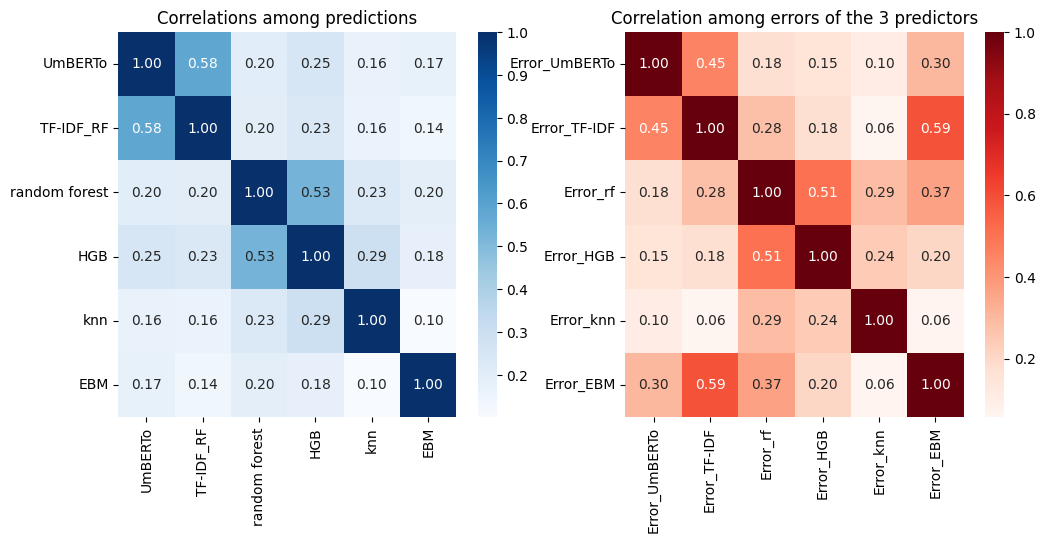

In [18]:
y_pred_umberto = np.argmax(umberto_probs, axis=1)
y_pred_tfidf = np.argmax(tfidf_probs, axis=1)
y_pred_ebm = np.argmax(ebm_probs, axis=1)
y_pred_knn = np.argmax(knn_probs, axis=1)
y_pred_gb = np.argmax(gb_probs, axis=1)
y_pred_rf = np.argmax(rf_probs, axis=1)


preds_df = pd.DataFrame({
    'UmBERTo': y_pred_umberto,
    'TF-IDF_RF': y_pred_tfidf,
    'random forest': y_pred_rf,
    'HGB': y_pred_gb,
    'knn': y_pred_knn,
    'EBM': y_pred_ebm
})

corr_matrix = preds_df.corr()


print("="*50)
print(corr_matrix)

def agreement_rate(p1, p2):
    return np.mean(p1 == p2)

print(f"\nAgreement UmBERTo vs TF-IDF: {agreement_rate(y_pred_umberto, y_pred_tfidf):.2%}")
print(f"Agreement UmBERTo vs EBM:     {agreement_rate(y_pred_umberto, y_pred_ebm):.2%}")
print(f"Agreement TF-IDF vs EBM:     {agreement_rate(y_pred_tfidf, y_pred_ebm):.2%}")
print(f"Agreement TF-IDF vs RF:     {agreement_rate(y_pred_tfidf, y_pred_rf):.2%}")
print(f"Agreement UmBERTo vs knn:     {agreement_rate(y_pred_umberto, y_pred_knn):.2%}")
print(f"Agreement HGB vs RF:     {agreement_rate(y_pred_gb, y_pred_rf):.2%}")

errors_df = pd.DataFrame({
    'Error_UmBERTo': (y_pred_umberto != y_true).astype(int),
    'Error_TF-IDF': (y_pred_tfidf != y_true).astype(int),
    'Error_rf': (y_pred_rf != y_true).astype(int),
    'Error_HGB': (y_pred_gb != y_true).astype(int),
    'Error_knn': (y_pred_knn != y_true).astype(int),
    'Error_EBM': (y_pred_ebm != y_true).astype(int),
})

error_corr = errors_df.corr()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title('Correlations among predictions')

plt.subplot(1, 2, 2)
sns.heatmap(error_corr, annot=True, cmap='Reds', fmt=".2f")
plt.title('Correlation among errors of the 3 predictors')

plt.show()

In [19]:
p_list_full = [
    np.squeeze(np.asarray(umberto_probs)),
    np.squeeze(np.asarray(tfidf_probs)),
    np.squeeze(np.asarray(rf_probs)),
    np.squeeze(np.asarray(gb_probs)),
    np.squeeze(np.asarray(knn_probs)),
    np.squeeze(np.asarray(ebm_probs))
]
model_names_full = ["UmBERTo", "TF-IDF", "Random Forest", "HistGB", "KNN", "EBM"]

select = [0,1,2,3,4,5]
p_list = [p_list_full[i] for i in select]
model_names = [model_names_full[i] for i in select]

unique_labels = np.unique(y_val)
class_weights = compute_class_weight(class_weight='balanced', classes=unique_labels, y=y_val)
class_weights_dict = dict(zip(unique_labels, class_weights))
weights_per_sample = np.array([class_weights_dict[label] for label in y_val])


for i, label_name in enumerate(le.classes_):

    print(f"- {label_name}: {class_weights[i]:.4f}") 


def weighted_loss_objective(weights, p_list, y_true, sample_weights):
    w = weights / np.sum(weights)
    
    ensemble_probs = sum(w[i] * p_list[i] for i in range(len(w)))
    
    return log_loss(y_true, ensemble_probs, sample_weight=sample_weights)

bounds = [(0, 1) for _ in range(len(p_list))]

result = differential_evolution(
    weighted_loss_objective,
    bounds,
    args=(p_list, y_val, weights_per_sample),
    strategy='best1bin', 
    popsize=50,           
    tol=0.01,
    mutation=(0.8, 1),   
    recombination=0.7
)

best_weights = result.x / np.sum(result.x)
final_probs = sum(best_weights[i] * p_list[i] for i in range(len(p_list)))
final_preds = np.argmax(final_probs, axis=1)

print(classification_report(y_true, final_preds, target_names=le.classes_))


print("="*60)
print("OPTIMIZED ENSEMBLE RESULTS")
print("="*60)

weight_str = ", ".join([f"{name}: {w:.4f}" for name, w in zip(model_names, best_weights)])
print(f"Optimal Weights: {weight_str}")
print("-" * 60)
print(f"Global Accuracy: {accuracy_score(y_val, final_preds):.4f}")
print("-" * 60)


- Center: 1.5456
- North: 0.4778
- South: 3.8475
              precision    recall  f1-score   support

      Center       0.70      0.55      0.61       234
       North       0.85      0.87      0.86       757
       South       0.59      0.76      0.66        94

    accuracy                           0.79      1085
   macro avg       0.71      0.73      0.71      1085
weighted avg       0.79      0.79      0.79      1085

OPTIMIZED ENSEMBLE RESULTS
Optimal Weights: UmBERTo: 0.7517, TF-IDF: 0.1180, Random Forest: 0.0000, HistGB: 0.0273, KNN: 0.1030, EBM: 0.0000
------------------------------------------------------------
Global Accuracy: 0.7926
------------------------------------------------------------


### Stacking

In [20]:
select = [0,1,3]
p_list = [p_list_full[i] for i in select]
model_names = [model_names_full[i] for i in select]

X_meta_all = np.hstack([p if p.ndim == 2 else p.reshape(-1, 1) for p in p_list])

X_meta_train, X_meta_test, y_meta_train, y_meta_test = train_test_split(
    X_meta_all, y_true, test_size=0.2, random_state=42, stratify=y_true
)

meta_models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=4, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, eval_metric='mlogloss')
}

model_performance = []

for name, model in meta_models.items():
    model.fit(X_meta_train, y_meta_train)
    
    preds = model.predict(X_meta_test)
    
    f1_macro = f1_score(y_meta_test, preds, average='macro')
    
    model_performance.append({
        'name': name,
        'model': model,
        'f1_macro': f1_macro,
        'preds': preds
    })

model_performance.sort(key=lambda x: x['f1_macro'], reverse=True)

print("="*60)
print(f"{'RANK':<5} | {'META-LEARNER':<20} | {'F1-SCORE (MACRO)':<15}")
print("-" * 60)

for i, res in enumerate(model_performance):
    print(f"{i+1:<5} | {res['name']:<20} | {res['f1_macro']:.4f}")

best = model_performance[0]
print("\n" + "="*60)
print(f"WINNER: {best['name']} (Detailed Report)")
print("="*60)
print(classification_report(y_meta_test, best['preds'], target_names=le.classes_))

RANK  | META-LEARNER         | F1-SCORE (MACRO)
------------------------------------------------------------
1     | XGBoost              | 0.7544
2     | Random Forest        | 0.7094
3     | Logistic Regression  | 0.6968

WINNER: XGBoost (Detailed Report)
              precision    recall  f1-score   support

      Center       0.75      0.51      0.61        47
       North       0.87      0.91      0.89       151
       South       0.64      0.95      0.77        19

    accuracy                           0.82       217
   macro avg       0.76      0.79      0.75       217
weighted avg       0.83      0.82      0.82       217



In [21]:
_, test_df_ = train_test_split(test_df, test_size=0.2, random_state=42, stratify=test_df['label'])

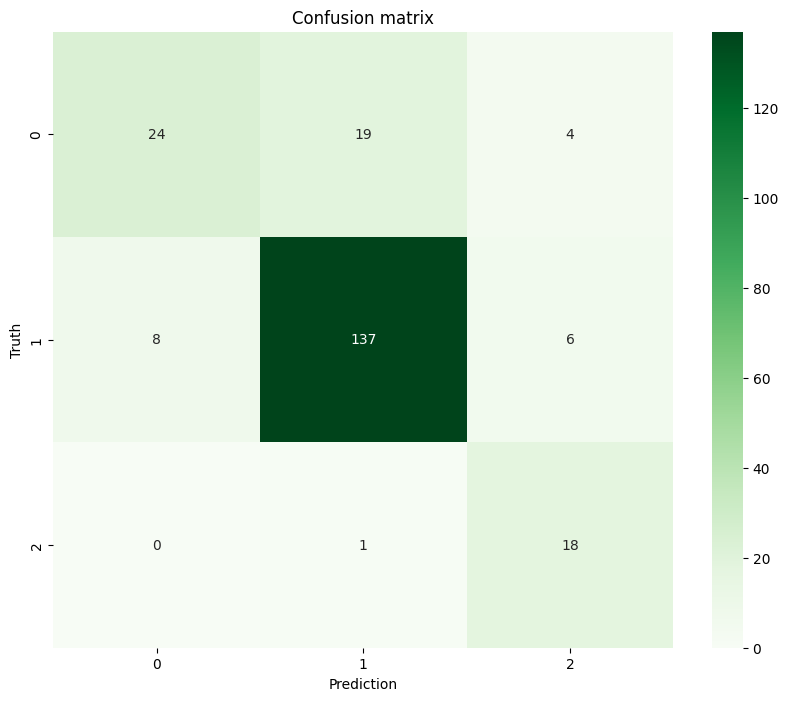

--------------------------------------------------
Songs predicted as south wrongly: 10
of which featurings:            5
percentage of featurings over false positives: 50.00%

True macro-zone of false-positive:
- Center: 4 songs
- North: 6 songs


In [22]:
south_idx = list(le.classes_).index('South')

df_analisi = pd.DataFrame({
    'real': y_meta_test,
    'pred': best['preds']
})

cm = confusion_matrix(y_meta_test, best['preds'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=tfidf.classes_, yticklabels=tfidf.classes_)
plt.title('Confusion matrix')
plt.ylabel('Truth')
plt.xlabel('Prediction')
plt.show()

df_analisi['is_collab'] = test_df_['is_collab'].values

fp_south = df_analisi[(df_analisi['pred'] == south_idx) & (df_analisi['real'] != south_idx)]

totale_fp_south = len(fp_south)
fp_south_collab = fp_south['is_collab'].sum()
percentuale_collab = (fp_south_collab / totale_fp_south * 100) if totale_fp_south > 0 else 0


print("-" * 50)
print(f"Songs predicted as south wrongly: {totale_fp_south}")
print(f"of which featurings:            {int(fp_south_collab)}")
print(f"percentage of featurings over false positives: {percentuale_collab:.2f}%")

if totale_fp_south > 0:
    print("\nTrue macro-zone of false-positive:")
    for i, label in enumerate(le.classes_):
        if i != south_idx:
            count = len(fp_south[fp_south['real'] == i])
            if count > 0:
                print(f"- {label}: {count} songs")